In [ ]:
import pandas as pd
import os
import json

# Define output directories
PROCESSED_DATA_DIR = '01_data/processed'
OUTPUT_DIR = '04_python'

# Create directories if they don't exist
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Output directories created: {PROCESSED_DATA_DIR}, {OUTPUT_DIR}")

Output directories created: 01_data/processed, 04_python


## Load Data

## Check Duplicates and Nulls

In [ ]:
# Load ledger.csv
try:
    df_ledger = pd.read_csv('/content/ledger.csv')
    print("ledger.csv loaded successfully.")
    display(df_ledger.head())
except FileNotFoundError:
    print("Error: ledger.csv not found. Please ensure the file is in '/content/'.")
    df_ledger = pd.DataFrame() # Create empty DataFrame to avoid errors

# Load gateway.csv
try:
    df_gateway = pd.read_csv('/content/gateway.csv')
    print("\ngateway.csv loaded successfully.")
    display(df_gateway.head())
except FileNotFoundError:
    print("Error: gateway.csv not found. Please ensure the file is in '/content/'.")
    df_gateway = pd.DataFrame() # Create empty DataFrame to avoid errors

ledger.csv loaded successfully.


,transaction_id,transaction_date,merchant_id,amount_usd,status,payment_method
0,R001,2026-03-01,M001,1200.0,success,UPI
1,R002,2026-03-01,M002,850.0,success,Card
2,R003,2026-03-02,M001,500.0,success,Wallet
3,R004,2026-03-02,M003,2100.0,success,Card
4,R005,2026-03-03,M004,7200.0,success,Card



gateway.csv loaded successfully.


,transaction_id,transaction_date,merchant_id,amount_usd,status,payment_method
0,R001,2026-03-01,M001,1200.0,success,UPI
1,R002,2026-03-01,M002,900.0,success,Card
2,R003,2026-03-02,M001,500.0,success,Wallet
3,R005,2026-03-03,M004,7200.0,failed,Card
4,R006,2026-03-03,M002,950.0,success,UPI


In [ ]:
summary_metrics = {}

# Check ledger.csv for duplicates and nulls
print("\n--- Ledger Data (ledger.csv) ---")
num_duplicates_ledger = df_ledger.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates_ledger}")
print("Null values per column:")
print(df_ledger.isnull().sum())

summary_metrics['ledger_total_records'] = len(df_ledger)
summary_metrics['ledger_duplicate_rows'] = num_duplicates_ledger
summary_metrics['ledger_null_values'] = df_ledger.isnull().sum().to_dict()

# Check gateway.csv for duplicates and nulls
print("\n--- Gateway Data (gateway.csv) ---")
num_duplicates_gateway = df_gateway.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates_gateway}")
print("Null values per column:")
print(df_gateway.isnull().sum())

summary_metrics['gateway_total_records'] = len(df_gateway)
summary_metrics['gateway_duplicate_rows'] = num_duplicates_gateway
summary_metrics['gateway_null_values'] = df_gateway.isnull().sum().to_dict()


--- Ledger Data (ledger.csv) ---
Number of duplicate rows: 0
Null values per column:
transaction_id      0
transaction_date    0
merchant_id         0
amount_usd          0
status              0
payment_method      0
dtype: int64

--- Gateway Data (gateway.csv) ---
Number of duplicate rows: 0
Null values per column:
transaction_id      0
transaction_date    0
merchant_id         0
amount_usd          0
status              0
payment_method      0
dtype: int64


## Identify Mismatches

Assuming 'transaction_id' is the unique identifier for reconciliation.

In [ ]:
# Merge dataframes for reconciliation
# Using an outer merge to catch records unique to each source
df_reconciliation = pd.merge(
    df_ledger.add_prefix('ledger_'),
    df_gateway.add_prefix('gateway_'),
    left_on='ledger_transaction_id',
    right_on='gateway_transaction_id',
    how='outer',
    suffixes=('_ledger', '_gateway')
)

# Identify records missing in gateway
missing_in_gateway = df_reconciliation[df_reconciliation['gateway_transaction_id'].isnull()]
print(f"\nRecords missing in Gateway: {len(missing_in_gateway)}")
display(missing_in_gateway)
missing_in_gateway.to_csv(os.path.join(PROCESSED_DATA_DIR, 'missing_in_gateway.csv'), index=False)
summary_metrics['records_missing_in_gateway'] = len(missing_in_gateway)

# Identify records missing in ledger
missing_in_ledger = df_reconciliation[df_reconciliation['ledger_transaction_id'].isnull()]
print(f"\nRecords missing in Ledger: {len(missing_in_ledger)}")
display(missing_in_ledger)
missing_in_ledger.to_csv(os.path.join(PROCESSED_DATA_DIR, 'missing_in_ledger.csv'), index=False)
summary_metrics['records_missing_in_ledger'] = len(missing_in_ledger)


Records missing in Gateway: 2


,ledger_transaction_id,ledger_transaction_date,ledger_merchant_id,ledger_amount_usd,ledger_status,ledger_payment_method,gateway_transaction_id,gateway_transaction_date,gateway_merchant_id,gateway_amount_usd,gateway_status,gateway_payment_method
3,R004,2026-03-02,M003,2100.0,success,Card,NaN,NaN,NaN,NaN,NaN,NaN
9,R010,2026-03-05,M004,2500.0,success,Wallet,NaN,NaN,NaN,NaN,NaN,NaN



Records missing in Ledger: 1


,ledger_transaction_id,ledger_transaction_date,ledger_merchant_id,ledger_amount_usd,ledger_status,ledger_payment_method,gateway_transaction_id,gateway_transaction_date,gateway_merchant_id,gateway_amount_usd,gateway_status,gateway_payment_method
10,NaN,NaN,NaN,NaN,NaN,NaN,R011,2026-03-05,M003,1800.0,success,Card


In [ ]:
# Focus on matched transactions for amount and status checks
df_matched = df_reconciliation.dropna(subset=['ledger_transaction_id', 'gateway_transaction_id'])

# Identify amount mismatches
amount_mismatches = df_matched[
    (df_matched['ledger_amount_usd'] != df_matched['gateway_amount_usd']) &
    df_matched['ledger_amount_usd'].notna() & df_matched['gateway_amount_usd'].notna()
]
print(f"\nAmount mismatches: {len(amount_mismatches)}")
display(amount_mismatches[['ledger_transaction_id', 'ledger_amount_usd', 'gateway_amount_usd']])
amount_mismatches.to_csv(os.path.join(PROCESSED_DATA_DIR, 'amount_mismatches.csv'), index=False)
summary_metrics['amount_mismatches'] = len(amount_mismatches)

# Identify status mismatches
status_mismatches = df_matched[
    (df_matched['ledger_status'] != df_matched['gateway_status']) &
    df_matched['ledger_status'].notna() & df_matched['gateway_status'].notna()
]
print(f"\nStatus mismatches: {len(status_mismatches)}")
display(status_mismatches[['ledger_transaction_id', 'ledger_status', 'gateway_status']])
status_mismatches.to_csv(os.path.join(PROCESSED_DATA_DIR, 'status_mismatches.csv'), index=False)
summary_metrics['status_mismatches'] = len(status_mismatches)


Amount mismatches: 2


,ledger_transaction_id,ledger_amount_usd,gateway_amount_usd
1,R002,850.0,900.0
7,R008,640.0,600.0



Status mismatches: 1


,ledger_transaction_id,ledger_status,gateway_status
4,R005,success,failed


## Build Final Reconciliation Report

In [ ]:
# Create a 'reconciliation_status' column in df_reconciliation
def get_reconciliation_status(row):
    if pd.isna(row['ledger_transaction_id']):
        return 'Missing in Ledger'
    elif pd.isna(row['gateway_transaction_id']):
        return 'Missing in Gateway'
    else:
        amount_match = (row['ledger_amount_usd'] == row['gateway_amount_usd']) or (pd.isna(row['ledger_amount_usd']) and pd.isna(row['gateway_amount_usd']))
        status_match = (row['ledger_status'] == row['gateway_status']) or (pd.isna(row['ledger_status']) and pd.isna(row['gateway_status']))

        if not amount_match and not status_match:
            return 'Amount & Status Mismatch'
        elif not amount_match:
            return 'Amount Mismatch'
        elif not status_match:
            return 'Status Mismatch'
        else:
            return 'Reconciled'

df_reconciliation['reconciliation_status'] = df_reconciliation.apply(get_reconciliation_status, axis=1)

# Save the final reconciliation report
reconciliation_report_path = os.path.join(PROCESSED_DATA_DIR, 'reconciliation_report.csv')
df_reconciliation.to_csv(reconciliation_report_path, index=False)
print(f"\nFinal Reconciliation Report saved to: {reconciliation_report_path}")
display(df_reconciliation.head())


Final Reconciliation Report saved to: 01_data/processed/reconciliation_report.csv


,ledger_transaction_id,ledger_transaction_date,ledger_merchant_id,ledger_amount_usd,ledger_status,ledger_payment_method,gateway_transaction_id,gateway_transaction_date,gateway_merchant_id,gateway_amount_usd,gateway_status,gateway_payment_method,reconciliation_status
0,R001,2026-03-01,M001,1200.0,success,UPI,R001,2026-03-01,M001,1200.0,success,UPI,Reconciled
1,R002,2026-03-01,M002,850.0,success,Card,R002,2026-03-01,M002,900.0,success,Card,Amount Mismatch
2,R003,2026-03-02,M001,500.0,success,Wallet,R003,2026-03-02,M001,500.0,success,Wallet,Reconciled
3,R004,2026-03-02,M003,2100.0,success,Card,NaN,NaN,NaN,NaN,NaN,NaN,Missing in Gateway
4,R005,2026-03-03,M004,7200.0,success,Card,R005,2026-03-03,M004,7200.0,failed,Card,Status Mismatch


## Generate Summary Metrics

In [ ]:
import numpy as np

# Custom JSON encoder to handle NumPy types
class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NpEncoder, self).default(obj)

# Add reconciliation summary to metrics
summary_metrics['reconciliation_summary'] = df_reconciliation['reconciliation_status'].value_counts().to_dict()

# Calculate additional metrics as per the new requirements
summary_metrics['total_ledger_rows'] = len(df_ledger)
summary_metrics['total_gateway_rows'] = len(df_gateway)
summary_metrics['missing_in_gateway_count'] = summary_metrics['records_missing_in_gateway']
summary_metrics['missing_in_ledger_count'] = summary_metrics['records_missing_in_ledger']
summary_metrics['amount_mismatch_count'] = summary_metrics['amount_mismatches']
summary_metrics['status_mismatch_count'] = summary_metrics['status_mismatches']

# Calculate reconciliation_issue_count (sum of all non-reconciled transactions)
issue_counts = [v for k, v in summary_metrics['reconciliation_summary'].items() if k != 'Reconciled']
summary_metrics['reconciliation_issue_count'] = sum(issue_counts)

# Calculate total amounts
summary_metrics['ledger_total_amount'] = df_ledger['amount_usd'].sum()
summary_metrics['gateway_total_amount'] = df_gateway['amount_usd'].sum()

# Calculate amount_at_risk (sum of ledger_amount_usd for non-reconciled transactions)
# Use ledger_amount_usd for transactions present in ledger, gateway_amount_usd for those only in gateway
amount_at_risk_df = df_reconciliation[df_reconciliation['reconciliation_status'] != 'Reconciled']

# Sum ledger_amount_usd for issues. For 'Missing in Ledger', we use gateway_amount_usd as ledger_amount_usd is NaN.
# For consistency, we can sum the non-null amount from either source for 'at-risk' transactions.
summary_metrics['amount_at_risk'] = amount_at_risk_df['ledger_amount_usd'].fillna(amount_at_risk_df['gateway_amount_usd']).sum()

# Remove old keys if they conflict with new naming for output
summary_metrics.pop('ledger_total_records', None)
summary_metrics.pop('gateway_total_records', None)
summary_metrics.pop('records_missing_in_gateway', None)
summary_metrics.pop('records_missing_in_ledger', None)
summary_metrics.pop('amount_mismatches', None)
summary_metrics.pop('status_mismatches', None)

# Save summary metrics to a JSON file using the custom encoder
summary_metrics_path = os.path.join(OUTPUT_DIR, 'summary_metrics.json')
with open(summary_metrics_path, 'w') as f:
    json.dump(summary_metrics, f, indent=4, cls=NpEncoder)

print(f"\nSummary metrics saved to: {summary_metrics_path}")
print("\n--- Reconciliation Summary Metrics ---")
display(summary_metrics)


Summary metrics saved to: 04_python/summary_metrics.json

--- Reconciliation Summary Metrics ---


{'ledger_duplicate_rows': np.int64(0),
 'ledger_null_values': {'transaction_id': 0,
  'transaction_date': 0,
  'merchant_id': 0,
  'amount_usd': 0,
  'status': 0,
  'payment_method': 0},
 'gateway_duplicate_rows': np.int64(0),
 'gateway_null_values': {'transaction_id': 0,
  'transaction_date': 0,
  'merchant_id': 0,
  'amount_usd': 0,
  'status': 0,
  'payment_method': 0},
 'reconciliation_summary': {'Reconciled': 5,
  'Amount Mismatch': 2,
  'Missing in Gateway': 2,
  'Status Mismatch': 1,
  'Missing in Ledger': 1},
 'total_ledger_rows': 10,
 'total_gateway_rows': 9,
 'missing_in_gateway_count': 2,
 'missing_in_ledger_count': 1,
 'amount_mismatch_count': 2,
 'status_mismatch_count': 1,
 'reconciliation_issue_count': 6,
 'ledger_total_amount': np.float64(23340.0),
 'gateway_total_amount': np.float64(20550.0),
 'amount_at_risk': np.float64(15090.0)}

## Visualization of Reconciliation Status

/tmp/ipykernel_14681/2427029465.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Status', y='Count', data=reconciliation_status_df, palette='viridis')


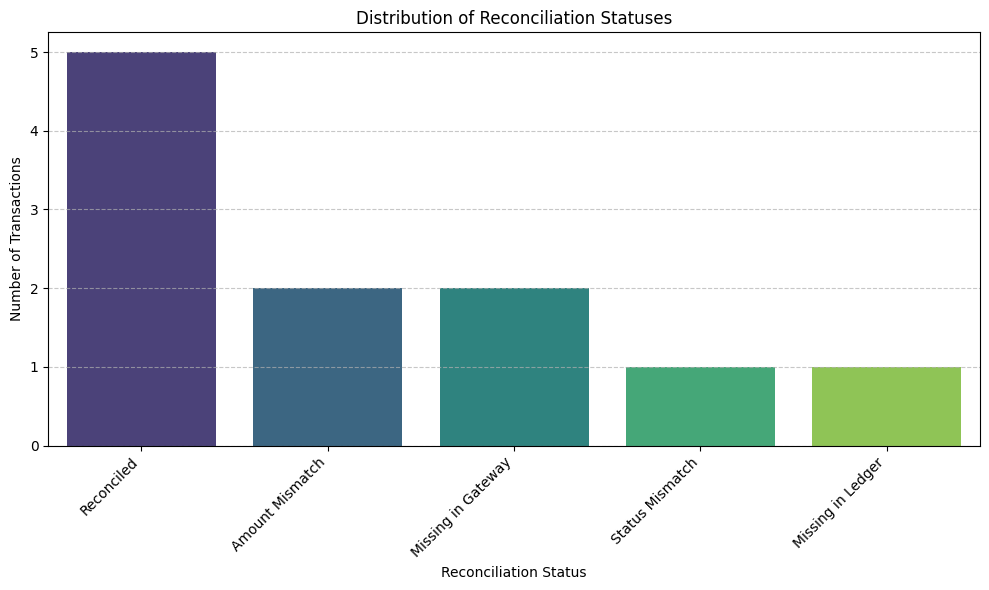

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
reconciliation_status_df = pd.DataFrame(summary_metrics['reconciliation_summary'].items(), columns=['Status', 'Count'])

# Sort for better visualization, e.g., by count or alphabetically
reconciliation_status_df = reconciliation_status_df.sort_values(by='Count', ascending=False)

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Status', y='Count', data=reconciliation_status_df, palette='viridis')
plt.title('Distribution of Reconciliation Statuses')
plt.xlabel('Reconciliation Status')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Convert Summary Metrics to CSV

## Part 4: JSON Normalization

In [ ]:
import json
import pandas as pd
from pandas import json_normalize

API_RESPONSE_FILE = '/content/api_response_sample.json'

try:
    with open(API_RESPONSE_FILE, 'r') as f:
        api_data = json.load(f)
    print(f"Successfully loaded {API_RESPONSE_FILE}")
    # Display a sample of the raw JSON data
    print("\nSample of raw JSON data:")
    display(api_data[0] if isinstance(api_data, list) else api_data)
except FileNotFoundError:
    print(f"Error: {API_RESPONSE_FILE} not found. Please ensure the file is in '/content/'.")
    api_data = []
except json.JSONDecodeError:
    print(f"Error: Could not decode JSON from {API_RESPONSE_FILE}. Invalid JSON format.")
    api_data = []

Successfully loaded /content/api_response_sample.json

Sample of raw JSON data:


{'generated_at': '2026-03-07T10:00:00Z',
 'source': 'QuickPay Settlement API',
 'batches': [{'batch_id': 'B001',
   'merchant': {'merchant_id': 'M001',
    'merchant_name': 'Alpha Mart',
    'region': 'APAC'},
   'settlements': [{'settlement_id': 'S001',
     'amount_usd': 1520.5,
     'status': 'settled',
     'processed_at': '2026-03-07T08:10:00Z',
     'bank': {'name': 'Bank A', 'country': 'IN'}},
    {'settlement_id': 'S002',
     'amount_usd': 980.0,
     'status': 'pending',
     'processed_at': '2026-03-07T08:45:00Z',
     'bank': {'name': 'Bank A', 'country': 'IN'}},
    {'settlement_id': 'S003',
     'amount_usd': 640.0,
     'status': 'settled',
     'processed_at': '2026-03-07T09:15:00Z',
     'bank': {'name': 'Bank B', 'country': 'SG'}}]},
  {'batch_id': 'B002',
   'merchant': {'merchant_id': 'M004',
    'merchant_name': 'Delta Travels',
    'region': 'US'},
   'settlements': [{'settlement_id': 'S004',
     'amount_usd': 2100.0,
     'status': 'settled',
     'processed_at'

### Flatten JSON into tabular form

In [ ]:
if api_data:
    # Flatten the JSON data
    # The 'settlements' list within 'batches' contains the main records.
    # Meta fields are extracted from the root ('generated_at', 'source') and the batch level ('batch_id', 'merchant' details).
    df_normalized = json_normalize(api_data,
                                   record_path=['batches', 'settlements'],
                                   meta=[
                                       ['generated_at'],
                                       ['source'],
                                       'batch_id',
                                       ['merchant', 'merchant_id'],
                                       ['merchant', 'merchant_name'],
                                       ['merchant', 'region']
                                   ],
                                   sep='_',
                                   errors='ignore')
    print("JSON data flattened successfully.")
    display(df_normalized.head())
else:
    print("No API data to flatten.")
    df_normalized = pd.DataFrame()

JSON data flattened successfully.


,settlement_id,amount_usd,status,processed_at,bank_name,bank_country,generated_at,source,batch_id,merchant_merchant_id,merchant_merchant_name,merchant_region
0,S001,1520.5,settled,2026-03-07T08:10:00Z,Bank A,IN,2026-03-07T10:00:00Z,QuickPay Settlement API,NaN,NaN,NaN,NaN
1,S002,980.0,pending,2026-03-07T08:45:00Z,Bank A,IN,2026-03-07T10:00:00Z,QuickPay Settlement API,NaN,NaN,NaN,NaN
2,S003,640.0,settled,2026-03-07T09:15:00Z,Bank B,SG,2026-03-07T10:00:00Z,QuickPay Settlement API,NaN,NaN,NaN,NaN
3,S004,2100.0,settled,2026-03-07T08:20:00Z,Bank C,US,2026-03-07T10:00:00Z,QuickPay Settlement API,NaN,NaN,NaN,NaN
4,S005,500.0,failed,2026-03-07T08:50:00Z,Bank C,US,2026-03-07T10:00:00Z,QuickPay Settlement API,NaN,NaN,NaN,NaN


### Clean column names

In [ ]:
if not df_normalized.empty:
    # Rename columns for clarity and consistency
    df_normalized.rename(columns={
        'settlement_id': 'transaction_id', # From settlements
        'amount_usd': 'transaction_amount',
        'status': 'transaction_status',
        'processed_at': 'transaction_date',
        'generated_at': 'api_request_timestamp', # From root meta
        'merchant_merchant_id': 'merchant_id',
        'merchant_merchant_name': 'merchant_name',
        'merchant_region': 'merchant_region'
    }, inplace=True)

    # Convert all column names to snake_case for consistency (handles bank_name, bank_country, etc.)
    df_normalized.columns = [col.lower().replace('.', '_').strip() for col in df_normalized.columns]
    print("Column names cleaned successfully.")
    display(df_normalized.head())
else:
    print("No data to clean column names for.")

Column names cleaned successfully.


,transaction_id,transaction_amount,transaction_status,transaction_date,bank_name,bank_country,api_request_timestamp,source,batch_id,merchant_id,merchant_name,merchant_region
0,S001,1520.5,settled,2026-03-07T08:10:00Z,Bank A,IN,2026-03-07T10:00:00Z,QuickPay Settlement API,NaN,NaN,NaN,NaN
1,S002,980.0,pending,2026-03-07T08:45:00Z,Bank A,IN,2026-03-07T10:00:00Z,QuickPay Settlement API,NaN,NaN,NaN,NaN
2,S003,640.0,settled,2026-03-07T09:15:00Z,Bank B,SG,2026-03-07T10:00:00Z,QuickPay Settlement API,NaN,NaN,NaN,NaN
3,S004,2100.0,settled,2026-03-07T08:20:00Z,Bank C,US,2026-03-07T10:00:00Z,QuickPay Settlement API,NaN,NaN,NaN,NaN
4,S005,500.0,failed,2026-03-07T08:50:00Z,Bank C,US,2026-03-07T10:00:00Z,QuickPay Settlement API,NaN,NaN,NaN,NaN


### Convert date/time fields

In [ ]:
if not df_normalized.empty:
    # Convert relevant columns to datetime objects
    date_cols = ['transaction_date', 'api_request_timestamp']
    for col in date_cols:
        if col in df_normalized.columns:
            df_normalized[col] = pd.to_datetime(df_normalized[col], errors='coerce')
    print("Date/time fields converted successfully.")
    display(df_normalized.info())
    display(df_normalized.head())
else:
    print("No data to convert date/time fields for.")

Date/time fields converted successfully.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   transaction_id         6 non-null      object             
 1   transaction_amount     6 non-null      float64            
 2   transaction_status     6 non-null      object             
 3   transaction_date       6 non-null      datetime64[ns, UTC]
 4   bank_name              6 non-null      object             
 5   bank_country           6 non-null      object             
 6   api_request_timestamp  6 non-null      datetime64[ns, UTC]
 7   source                 6 non-null      object             
 8   batch_id               0 non-null      object             
 9   merchant_id            0 non-null      object             
 10  merchant_name          0 non-null      object             
 11  merchant_region      

None

,transaction_id,transaction_amount,transaction_status,transaction_date,bank_name,bank_country,api_request_timestamp,source,batch_id,merchant_id,merchant_name,merchant_region
0,S001,1520.5,settled,2026-03-07 08:10:00+00:00,Bank A,IN,2026-03-07 10:00:00+00:00,QuickPay Settlement API,NaN,NaN,NaN,NaN
1,S002,980.0,pending,2026-03-07 08:45:00+00:00,Bank A,IN,2026-03-07 10:00:00+00:00,QuickPay Settlement API,NaN,NaN,NaN,NaN
2,S003,640.0,settled,2026-03-07 09:15:00+00:00,Bank B,SG,2026-03-07 10:00:00+00:00,QuickPay Settlement API,NaN,NaN,NaN,NaN
3,S004,2100.0,settled,2026-03-07 08:20:00+00:00,Bank C,US,2026-03-07 10:00:00+00:00,QuickPay Settlement API,NaN,NaN,NaN,NaN
4,S005,500.0,failed,2026-03-07 08:50:00+00:00,Bank C,US,2026-03-07 10:00:00+00:00,QuickPay Settlement API,NaN,NaN,NaN,NaN


### Save the normalized output

In [ ]:
if not df_normalized.empty:
    normalized_output_path = os.path.join(PROCESSED_DATA_DIR, 'api_normalized.csv')
    df_normalized.to_csv(normalized_output_path, index=False)
    print(f"Normalized data saved to: {normalized_output_path}")
else:
    print("No normalized data to save.")

Normalized data saved to: 01_data/processed/api_normalized.csv
